# G10 FX Monitor
**G10 · EUR Crosses · EM** — Technical · Carry · Macro  
Data: Bloomberg via `xbbg`

In [1]:
import sys
!{sys.executable} -m pip install itables -q
print("itables installed")

itables installed


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import warnings
from datetime import datetime, timedelta
from xbbg import blp
from itables import show

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:.2f}')

plt.rcParams.update({
    'figure.facecolor': 'white', 'axes.facecolor': 'white',
    'axes.edgecolor': '#cccccc', 'grid.color': '#eeeeee',
    'axes.labelcolor': '#222222', 'xtick.color': '#444444',
    'ytick.color': '#444444', 'text.color': '#222222',
})

BULL  = '#009933'
BEAR  = '#cc0000'
NEUT  = '#888888'
BLUE  = '#0066cc'
TODAY = datetime.today()

ITABLE_OPTS = dict(
    classes='display compact hover',
    style='width:100%',
    paging=False,
    searching=True,
    order=[],
    allow_html=True,
)

print(f'G10 FX Monitor  |  {TODAY.strftime("%d %b %Y %H:%M")}')

G10 FX Monitor  |  01 Sep 2026 14:21


---
## 1. Universe & Tickers

In [3]:
G10_PAIRS = [
    'EURUSD','GBPUSD','USDJPY','USDCHF','USDCAD',
    'AUDUSD','NZDUSD','EURGBP','EURJPY','GBPJPY',
    'AUDJPY','CADJPY','NZDCHF','EURCHF','AUDNZD',
    'EURNOK','USDNOK','EURSEK','USDSEK',
]

EM_PAIRS = [
    'USDBRL','USDMXN','USDCLP','USDCOP',
    'EURHUF','USDPLN','EURCZK',
    'USDZAR','USDKRW','USDIDR',
]

ALL_PAIRS = G10_PAIRS + EM_PAIRS

RATE_3M_TICKERS = {
    'USD':'DCPB090D Index', 'EUR':'EURI3M Curncy',  'GBP':'GBPI3M Curncy',
    'JPY':'JPYI3M Curncy',  'CHF':'CHFI3M Curncy',  'CAD':'CADI3M Curncy',
    'AUD':'AUDI3M Curncy',  'NZD':'NZDI3M Curncy',  'NOK':'NOKI3M Curncy',
    'SEK':'SEKI3M Curncy',  'BRL':'BCNI3M BGN Curncy','MXN':'MXNI3M Curncy',
    'CLP':'CHNI3M BGN Curncy','COP':'CLNI3M Curncy','HUF':'HUFI3M Curncy',
    'PLN':'PLNI3M Curncy',  'CZK':'CZKI3M Curncy',  'ZAR':'ZARI3M Curncy',
    'KRW':'KRWI3M Curncy',  'IDR':'IDRI3M Curncy',
}

CPI_TICKERS = {
    'USD':'CPI YOY Index',   'EUR':'ECCPEMUY Index', 'GBP':'UKRPCJYR Index',
    'JPY':'JNCPIYOY Index',  'CHF':'SZCPIYOY Index', 'CAD':'CACPIYOY Index',
    'AUD':'AUCPIYOY Index',  'NZD':'NZCPIYOY Index', 'NOK':'NOCPIYOY Index',
    'SEK':'SWCPIYOY Index',  'BRL':'BZPIIPCA Index', 'MXN':'MXCPIYOY Index',
    'CLP':'CLCPIYOY Index',  'COP':'COCPIYOY Index', 'HUF':'HUCPIYOY Index',
    'PLN':'POCPIYOY Index',  'CZK':'CZCPIYOY Index', 'ZAR':'SACPIYOY Index',
    'KRW':'KOCPIYOY Index',  'IDR':'IDCPIYOY Index',
}

PMI_TICKERS = {
    'USD':'MPMIUSCA Index', 'EUR':'MPMIEZCA Index', 'GBP':'MPMIGBCA Index',
    'JPY':'MPMIJPCA Index', 'CHF':'SVPMICOM Index', 'CAD':'IVEYPMIS Index',
    'AUD':'MPMIAUCA Index', 'NZD':'BNNZPMI Index',  'NOK':'NOPMISA Index',
    'SEK':'PMISCMPS Index', 'BRL':'MPMIBZCA Index', 'MXN':'MXPMIMAN Index',
    'CLP': None,            'COP':'MPMICOCA Index', 'HUF': None,
    'PLN':'MPMIPLMF Index', 'CZK':'MPMICZMA Index', 'ZAR':'MPMIZAMA Index',
    'KRW':'MPMIKRCA Index', 'IDR':'MPMIIDCA Index',
}

POLICY_TICKERS = {
    'USD':'FDTRMJNK Index', 'EUR':'EURR002W Index', 'GBP':'UKBRBASE Index',
    'JPY':'BOJDPBAL Index', 'CHF':'SZLTTR Index',   'CAD':'CABROVER Index',
    'AUD':'RBATCTR Index',  'NZD':'RBNZOCR Index',  'NOK':'NOBRDEPA Index',
    'SEK':'SWRRATMN Index', 'BRL':'BZSTSETA Index', 'MXN':'MXONBR Index',
    'CLP':'CHPBREPR Index', 'COP':'COBRRMIN Index', 'HUF':'HUGBBASE Index',
    'PLN':'POREFINR Index', 'CZK':'CZTXRBOR Index', 'ZAR':'SAREPOPM Index',
    'KRW':'KOBASE Index',   'IDR':'IDBIRATE Index',
}

CB_BIAS = {
    'USD': 0, 'EUR':-1, 'GBP':-1, 'JPY': 1, 'CHF':-1,
    'CAD':-1, 'AUD': 0, 'NZD':-1, 'NOK': 0, 'SEK':-1,
    'BRL': 1, 'MXN':-1, 'CLP': 0, 'COP': 0, 'HUF':-1,
    'PLN': 0, 'CZK':-1, 'ZAR': 0, 'KRW':-1, 'IDR': 0,
}
CB_LABEL = {1:'Hawkish', 0:'Neutral', -1:'Dovish'}

LOOKBACK = {'1m': 21, '3m': 63, '1y': 252}
HIST_DAYS = 420

print(f'Universe: {len(G10_PAIRS)} G10 pairs + {len(EM_PAIRS)} EM pairs = {len(ALL_PAIRS)} total')

Universe: 19 G10 pairs + 10 EM pairs = 29 total


---
## 2. Bloomberg Data Fetch

In [4]:
START = (TODAY - timedelta(days=HIST_DAYS)).strftime('%Y-%m-%d')
END   = TODAY.strftime('%Y-%m-%d')

def bdh(tickers, field='PX_LAST', start=START, end=END):
    """Fetch historical data; returns DataFrame columns=tickers."""
    if isinstance(tickers, str):
        tickers = [tickers]
    raw = blp.bdh(tickers=tickers, flds=field, start_date=start, end_date=end)
    if raw.empty:
        return pd.DataFrame()
    raw.columns = [c[0] if isinstance(c, tuple) else c for c in raw.columns]
    return raw

def bdp(tickers, field='PX_LAST'):
    """Fetch latest reference data; returns Series."""
    if isinstance(tickers, list):
        raw = blp.bdp(tickers=tickers, flds=field)
    else:
        raw = blp.bdp(tickers=list(tickers.values()), flds=field)
    return raw[field] if field in raw.columns else raw.iloc[:, 0]

# ── Spot OHLC ────────────────────────────────────────────────────────────────
print('Fetching spot prices...')
spot_tickers = [f'{p} Curncy' for p in ALL_PAIRS]
close = bdh(spot_tickers).rename(columns=lambda c: c.replace(' Curncy',''))
high  = bdh(spot_tickers, 'PX_HIGH').rename(columns=lambda c: c.replace(' Curncy',''))
low   = bdh(spot_tickers, 'PX_LOW').rename(columns=lambda c: c.replace(' Curncy',''))
print(f'  Spot loaded: {len(close)} sessions, {len(close.columns)} pairs')

# ── 3m rates ─────────────────────────────────────────────────────────────────
print('Fetching 3m rates...')
rate_s = bdp(list(RATE_3M_TICKERS.values()))
inv_rate = {v: k for k, v in RATE_3M_TICKERS.items()}
rates_3m = rate_s.rename(index=inv_rate).astype(float)

# ── CPI ──────────────────────────────────────────────────────────────────────
print('Fetching CPI...')
valid_cpi = {k: v for k, v in CPI_TICKERS.items() if v}
cpi_s = bdp(list(valid_cpi.values()))
cpi_latest = cpi_s.rename(index={v: k for k, v in valid_cpi.items()}).astype(float)

# ── PMI ───────────────────────────────────────────────────────────────────────
print('Fetching PMI...')
valid_pmi = {k: v for k, v in PMI_TICKERS.items() if v}
pmi_s = bdp(list(valid_pmi.values()))
pmi_latest = pmi_s.rename(index={v: k for k, v in valid_pmi.items()}).astype(float)

# ── Policy rates ──────────────────────────────────────────────────────────────
print('Fetching policy rates...')
pol_s = bdp(list(POLICY_TICKERS.values()))
policy_rates = pol_s.rename(index={v: k for k, v in POLICY_TICKERS.items()}).astype(float)

print(f'\nAll data loaded  |  as of {TODAY.strftime("%d %b %Y")}')

Fetching spot prices...
  Spot loaded: 301 sessions, 29 pairs
Fetching 3m rates...
Fetching CPI...
Fetching PMI...
Fetching policy rates...

All data loaded  |  as of 01 Sep 2026


---
## 3. Signal Computation

In [5]:
# ── Technical helpers ─────────────────────────────────────────────────────────

def compute_rsi(px, w=14):
    d = px.diff()
    gain = d.clip(lower=0).ewm(alpha=1/w, min_periods=w).mean()
    loss = (-d.clip(upper=0)).ewm(alpha=1/w, min_periods=w).mean()
    return 100 - (100 / (1 + gain / loss.replace(0, np.nan)))

def compute_macd(px, fast=12, slow=26, sig=9):
    m = px.ewm(span=fast, adjust=False).mean() - px.ewm(span=slow, adjust=False).mean()
    s = m.ewm(span=sig, adjust=False).mean()
    return pd.DataFrame({'macd': m, 'signal': s, 'histogram': m - s})

def compute_bollinger(px, w=20, n=2):
    mid = px.rolling(w).mean()
    std = px.rolling(w).std()
    return pd.DataFrame({'mid': mid, 'upper': mid+n*std, 'lower': mid-n*std,
                         'pct_b': (px - (mid-n*std)) / (2*n*std).replace(0, np.nan)})

def compute_adx(h, l, c, w=14):
    tr = pd.concat([h-l, (h-c.shift()).abs(), (l-c.shift()).abs()], axis=1).max(axis=1)
    dm_p = (h-h.shift()).clip(lower=0)
    dm_m = (l.shift()-l).clip(lower=0)
    dm_p = dm_p.where(dm_p > dm_m, 0)
    dm_m = dm_m.where(dm_m > dm_p, 0)
    atr = tr.ewm(alpha=1/w, min_periods=w).mean()
    di_p = 100 * dm_p.ewm(alpha=1/w, min_periods=w).mean() / atr
    di_m = 100 * dm_m.ewm(alpha=1/w, min_periods=w).mean() / atr
    dx = 100 * (di_p-di_m).abs() / (di_p+di_m).replace(0, np.nan)
    return dx.ewm(alpha=1/w, min_periods=w).mean()

def zscore(px, w):
    s = px.dropna()
    if len(s) < w//2: return np.nan
    mu, sd = s.rolling(w).mean().iloc[-1], s.rolling(w).std().iloc[-1]
    return (s.iloc[-1] - mu) / sd if sd and not np.isnan(sd) else np.nan

def roc(px, w):
    s = px.dropna()
    return (s.iloc[-1]/s.iloc[-(w+1)] - 1)*100 if len(s) > w else np.nan

# ── Build all signals ─────────────────────────────────────────────────────────
tech_rows, carry_rows, macro_rows = [], [], []

for pair in ALL_PAIRS:
    if pair not in close.columns:
        continue
    base, quote = pair[:3], pair[3:]
    px = close[pair].dropna()
    if len(px) < 60:
        continue
    h  = high[pair].reindex(px.index) if pair in high.columns else px
    l  = low[pair].reindex(px.index)  if pair in low.columns  else px

    # ── TECHNICAL ────────────────────────────────────────────────────────────
    rsi_v  = compute_rsi(px).iloc[-1]
    macd_v = compute_macd(px)
    bb_v   = compute_bollinger(px)
    adx_v  = compute_adx(h, l, px).iloc[-1]
    hist   = macd_v['histogram']
    macd_lbl = ('Bullish ↑' if hist.iloc[-1]>0 and hist.iloc[-1]>hist.iloc[-2] else
                'Bearish ↓' if hist.iloc[-1]<0 and hist.iloc[-1]<hist.iloc[-2] else
                'Bullish ~' if hist.iloc[-1]>0 else
                'Bearish ~' if hist.iloc[-1]<0 else 'Neutral')
    sma20  = px.rolling(20).mean().iloc[-1]
    sma50  = px.rolling(50).mean().iloc[-1]
    sma200 = px.rolling(200).mean().iloc[-1]

    tech_rows.append({
        'pair': pair,
        'RSI(14)':   round(rsi_v, 1),
        'RSI Zone':  'Overbought' if rsi_v>=70 else 'Oversold' if rsi_v<=30 else 'Neutral',
        'MACD':      macd_lbl,
        'SMA 20/50': 'Bull' if sma20>sma50 else 'Bear',
        'SMA 50/200':'Bull' if sma50>sma200 else 'Bear',
        'ROC 1m %':  round(roc(px, LOOKBACK['1m']), 2),
        'ROC 3m %':  round(roc(px, LOOKBACK['3m']), 2),
        'BB %B':     round(bb_v['pct_b'].iloc[-1], 3),
        'ADX(14)':   round(adx_v, 1) if not np.isnan(adx_v) else np.nan,
        'Trend':     'Strong' if adx_v>=40 else 'Trending' if adx_v>=25 else 'Weak',
        'Z 1m':      round(zscore(px, 21), 2),
        'Z 3m':      round(zscore(px, 63), 2),
        'Z 1Y':      round(zscore(px, 252), 2),
    })

    # ── CARRY  (convention: Quote - Base) ───────────────────────────────────
    r_b = rates_3m.get(base, np.nan)
    r_q = rates_3m.get(quote, np.nan)
    diff_bps = (r_q - r_b) * 100 if not (pd.isna(r_b) or pd.isna(r_q)) else np.nan

    cpi_b = cpi_latest.get(base, np.nan)
    cpi_q = cpi_latest.get(quote, np.nan)
    cpi_diff = (cpi_q - cpi_b) if not (pd.isna(cpi_b) or pd.isna(cpi_q)) else np.nan
    real_carry = (diff_bps - cpi_diff * 100) if not (pd.isna(diff_bps) or pd.isna(cpi_diff)) else np.nan

    log_ret = np.log(px / px.shift(1)).dropna()
    rvol1m  = log_ret.iloc[-LOOKBACK['1m']:].std() * np.sqrt(252) * 100
    rvol3m  = log_ret.iloc[-LOOKBACK['3m']:].std() * np.sqrt(252) * 100
    cv1m = round(diff_bps / (rvol1m * 100), 4) if rvol1m else np.nan
    cv3m = round(diff_bps / (rvol3m * 100), 4) if rvol3m else np.nan

    rv_roll = log_ret.rolling(21).std() * np.sqrt(252) * 100
    avg6m   = rv_roll.rolling(126).mean().iloc[-1]
    regime  = ('High' if rvol1m/avg6m>1.3 else 'Low' if rvol1m/avg6m<0.7 else 'Normal') if avg6m else 'N/A'

    carry_rows.append({
        'pair': pair,
        'Base': base, 'Quote': quote,
        'Base 3m %':          round(r_b, 3) if not pd.isna(r_b) else np.nan,
        'Quote 3m %':         round(r_q, 3) if not pd.isna(r_q) else np.nan,
        'Rate Diff 3m (bps)': round(diff_bps, 1) if not pd.isna(diff_bps) else np.nan,
        'Real Carry (bps)':   round(real_carry, 1) if not pd.isna(real_carry) else np.nan,
        'CPI Diff %':         round(cpi_diff, 2) if not pd.isna(cpi_diff) else np.nan,
        'RVol 1m %':          round(rvol1m, 2),
        'RVol 3m %':          round(rvol3m, 2),
        'Carry/Vol 1m':       cv1m,
        'Carry/Vol 3m':       cv3m,
        'Vol Regime':         regime,
    })

    # ── MACRO ────────────────────────────────────────────────────────────────
    pmi_b = pmi_latest.get(base, np.nan)
    pmi_q = pmi_latest.get(quote, np.nan)
    pmi_diff = (pmi_b - pmi_q) if not (pd.isna(pmi_b) or pd.isna(pmi_q)) else np.nan
    pmi_lbl  = ('Strong Bull' if pmi_diff>2 else 'Mild Bull' if pmi_diff>0 else
                'Strong Bear' if pmi_diff<-2 else 'Mild Bear' if pmi_diff<0 else 'Neutral') if not pd.isna(pmi_diff) else 'N/A'

    pr_b = policy_rates.get(base, np.nan)
    pr_q = policy_rates.get(quote, np.nan)
    pol_diff = (pr_b - pr_q)*100 if not (pd.isna(pr_b) or pd.isna(pr_q)) else np.nan

    cb_b = CB_BIAS.get(base, 0)
    cb_q = CB_BIAS.get(quote, 0)

    macro_rows.append({
        'pair': pair,
        'PMI Base':     round(pmi_b, 1) if not pd.isna(pmi_b) else np.nan,
        'PMI Quote':    round(pmi_q, 1) if not pd.isna(pmi_q) else np.nan,
        'PMI Diff':     round(pmi_diff, 1) if not pd.isna(pmi_diff) else np.nan,
        'PMI Signal':   pmi_lbl,
        'CPI Base YoY': round(cpi_b, 2) if not pd.isna(cpi_b) else np.nan,
        'CPI Quote YoY':round(cpi_q, 2) if not pd.isna(cpi_q) else np.nan,
        'CPI Diff %':   round(cpi_diff, 2) if not pd.isna(cpi_diff) else np.nan,
        'CB Base':      CB_LABEL.get(cb_b, 'N/A'),
        'CB Quote':     CB_LABEL.get(cb_q, 'N/A'),
        'CB Diff':      cb_b - cb_q,
        'Policy Δ bps': round(pol_diff, 1) if not pd.isna(pol_diff) else np.nan,
    })

tech  = pd.DataFrame(tech_rows).set_index('pair')
carry = pd.DataFrame(carry_rows).set_index('pair')
macro = pd.DataFrame(macro_rows).set_index('pair')

print(f'Signals computed for {len(tech)} pairs')

Signals computed for 29 pairs


---
## 4. Technical Signals

In [6]:
def color_signal(val, col):
    bull_labels = {'Bull','Bullish ↑','Bullish ~','Oversold','Strong Bull','Mild Bull','Strong','Trending'}
    bear_labels = {'Bear','Bearish ↓','Bearish ~','Overbought','Strong Bear','Mild Bear','Weak'}
    if col in ('RSI Zone','MACD','SMA 20/50','SMA 50/200','Trend','PMI Signal','CB Base','CB Quote'):
        if str(val) in bull_labels: return f'color: {BULL}; font-weight: bold'
        if str(val) in bear_labels: return f'color: {BEAR}; font-weight: bold'
        return f'color: {NEUT}'
    if col in ('ROC 1m %','ROC 3m %','Z 1m','Z 3m','Z 1Y',
               'Rate Diff 3m (bps)','Real Carry (bps)','Carry/Vol 1m','Carry/Vol 3m',
               'PMI Diff','CPI Diff %','CB Diff','Policy Δ bps'):
        try:
            v = float(val)
            if not np.isnan(v):
                return f'color: {BULL}; font-weight: bold' if v > 0 else f'color: {BEAR}; font-weight: bold'
        except: pass
    return ''

def style_df(df):
    return df.style.apply(
        lambda col: [color_signal(v, col.name) for v in col], axis=0
    ).format(na_rep='N/A', precision=2)

print(f'=== TECHNICAL SIGNALS  |  {TODAY.strftime("%d %b %Y")} ===')
show(style_df(tech), **ITABLE_OPTS)

=== TECHNICAL SIGNALS  |  01 Sep 2026 ===


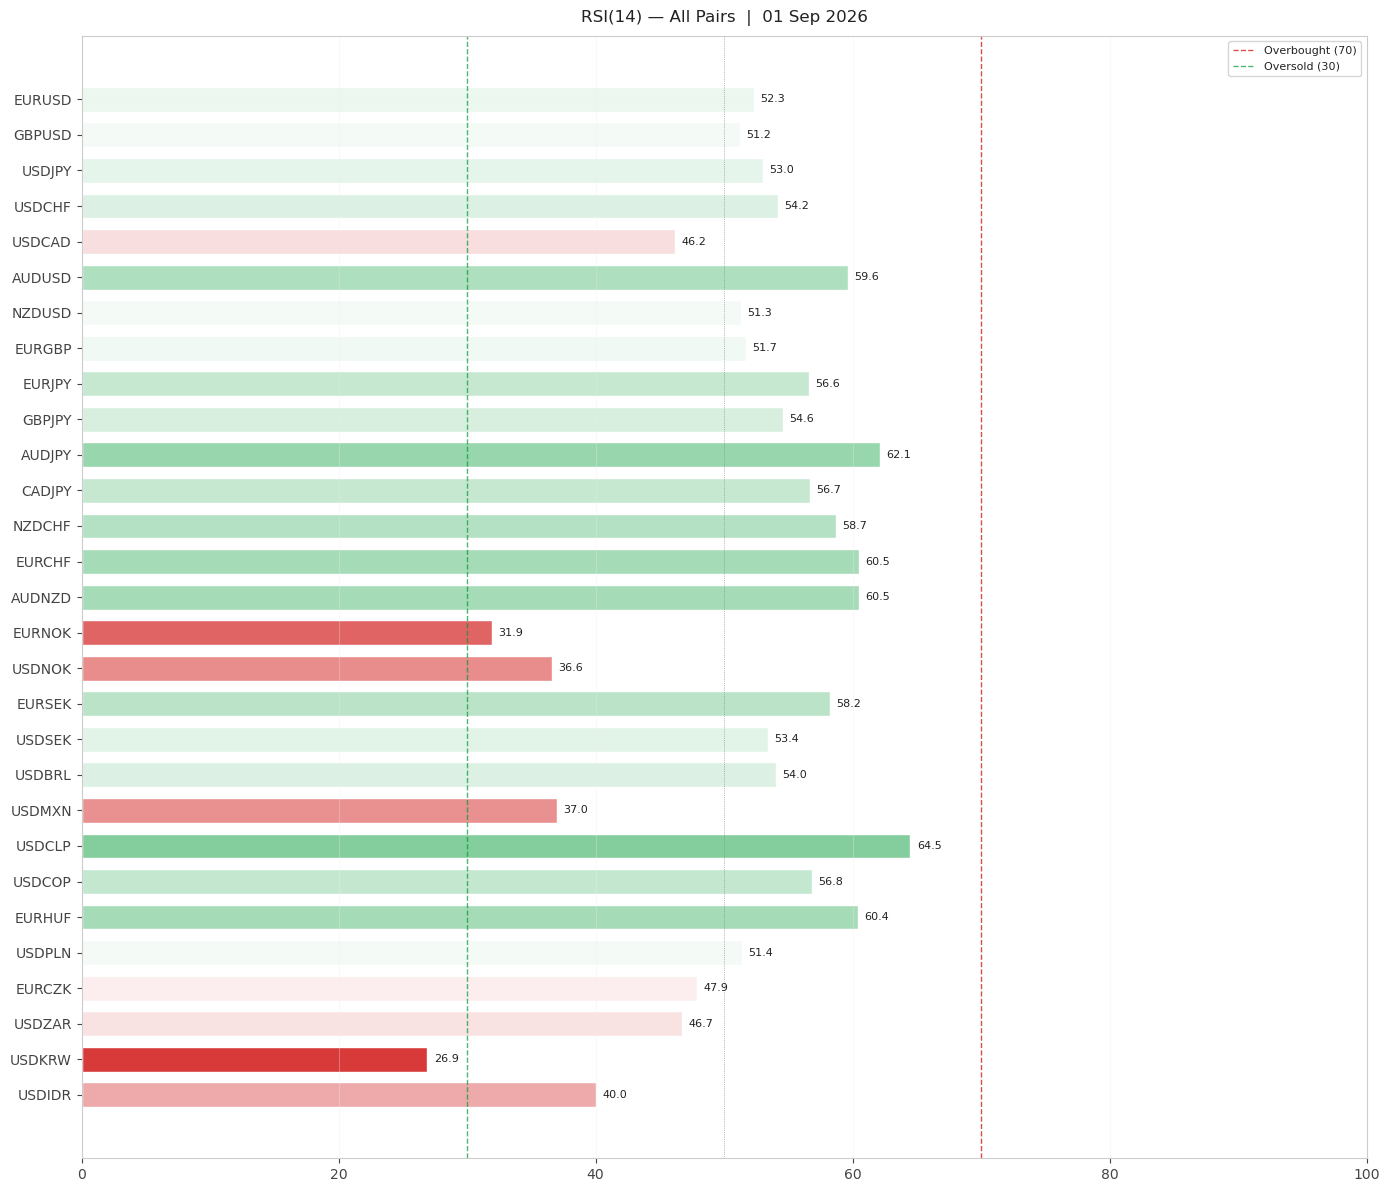

In [7]:
# ── RSI Heatmap ───────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, len(tech)*0.38 + 1))
rsi_vals = tech['RSI(14)'].values
norm = plt.Normalize(20, 80)
cmap = mcolors.LinearSegmentedColormap.from_list('rsi', [BEAR, '#ffffff', BULL])
colors = [cmap(norm(v)) if not np.isnan(v) else (0.9,0.9,0.9,1) for v in rsi_vals]
bars = ax.barh(tech.index[::-1], rsi_vals[::-1], color=colors[::-1], edgecolor='white', height=0.7)
ax.axvline(70, color=BEAR, lw=1, ls='--', alpha=0.7, label='Overbought (70)')
ax.axvline(30, color=BULL, lw=1, ls='--', alpha=0.7, label='Oversold (30)')
ax.axvline(50, color='grey', lw=0.5, ls=':')
for bar, val in zip(bars[::-1], rsi_vals):
    if not np.isnan(val):
        ax.text(val + 0.5, bar.get_y() + bar.get_height()/2, f'{val:.1f}',
                va='center', fontsize=8)
ax.set_xlim(0, 100)
ax.set_title(f'RSI(14) — All Pairs  |  {TODAY.strftime("%d %b %Y")}', fontsize=12, pad=10)
ax.legend(fontsize=8)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('monitor_rsi.png', dpi=150, bbox_inches='tight')
plt.show()

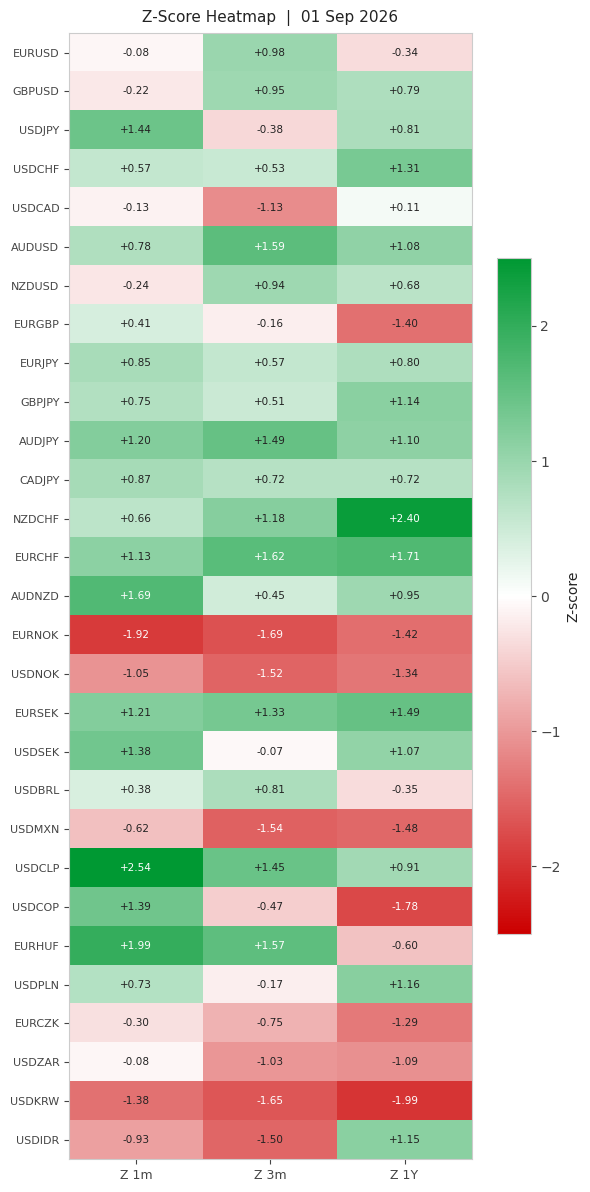

In [8]:
# ── Z-Score Heatmap ───────────────────────────────────────────────────────────
z_cols = ['Z 1m', 'Z 3m', 'Z 1Y']
z_data = tech[z_cols].astype(float)

fig, ax = plt.subplots(figsize=(6, len(z_data)*0.38 + 1))
cmap2 = mcolors.LinearSegmentedColormap.from_list('zscore', [BEAR, '#ffffff', BULL])
im = ax.imshow(z_data.values, cmap=cmap2, vmin=-2.5, vmax=2.5, aspect='auto')
ax.set_xticks(range(len(z_cols)))
ax.set_xticklabels(z_cols, fontsize=9)
ax.set_yticks(range(len(z_data)))
ax.set_yticklabels(z_data.index, fontsize=8)
for i in range(len(z_data)):
    for j, col in enumerate(z_cols):
        v = z_data.iloc[i, j]
        if not np.isnan(v):
            ax.text(j, i, f'{v:+.2f}', ha='center', va='center', fontsize=7.5,
                    color='white' if abs(v) > 1.5 else '#222222')
plt.colorbar(im, ax=ax, label='Z-score', shrink=0.6)
ax.set_title(f'Z-Score Heatmap  |  {TODAY.strftime("%d %b %Y")}', fontsize=11, pad=8)
plt.tight_layout()
plt.savefig('monitor_zscore.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 5. Carry

In [9]:
print(f'=== CARRY  |  Convention: Quote(CCY2) − Base(CCY1)  |  {TODAY.strftime("%d %b %Y")} ===')
show(style_df(carry.drop(columns=['Base','Quote'])), **ITABLE_OPTS)

=== CARRY  |  Convention: Quote(CCY2) − Base(CCY1)  |  01 Sep 2026 ===


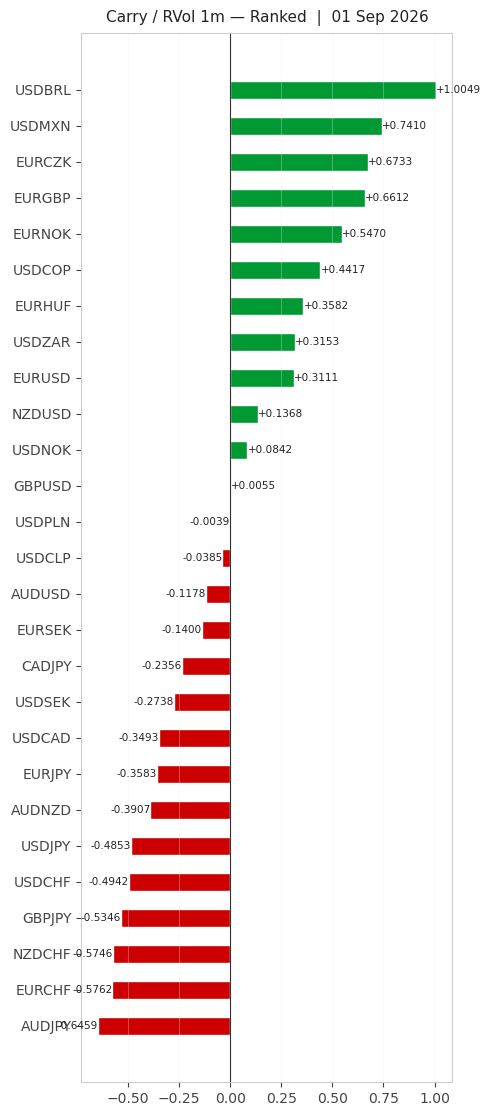

In [16]:
# ── Carry/Vol ranking bar chart ───────────────────────────────────────────────
cv = carry['Carry/Vol 1m'].dropna().sort_values(ascending=True)
colors = [BULL if v > 0 else BEAR for v in cv.values]

fig, ax = plt.subplots(figsize=(5, len(cv)*0.38 + 1))
ax.barh(cv.index, cv.values, color=colors, edgecolor='white', height=0.5)
ax.axvline(0, color='#333333', lw=0.8)
for i, (idx, val) in enumerate(cv.items()):
    ax.text(val + (0.0002 if val >= 0 else -0.0002), i, f'{val:+.4f}',
            va='center', ha='left' if val >= 0 else 'right', fontsize=7.5)
ax.set_title(f'Carry / RVol 1m — Ranked  |  {TODAY.strftime("%d %b %Y")}', fontsize=11, pad=8)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('monitor_carry.png', dpi=100, bbox_inches='tight')
plt.show()

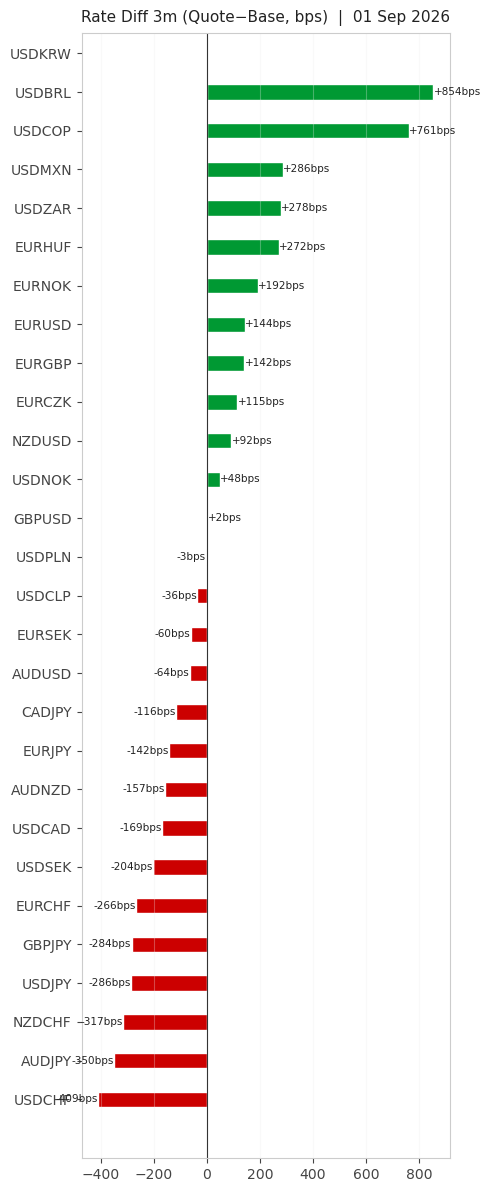

In [17]:
# ── Rate Diff heatmap ─────────────────────────────────────────────────────────
rd = carry['Rate Diff 3m (bps)'].sort_values(ascending=True)
colors = [BULL if v > 0 else BEAR for v in rd.values]

fig, ax = plt.subplots(figsize=(5, len(rd)*0.38 + 1))
ax.barh(rd.index, rd.values, color=colors, edgecolor='white', height=0.4)
ax.axvline(0, color='#333333', lw=0.8)
for i, (idx, val) in enumerate(rd.items()):
    ax.text(val + (1 if val >= 0 else -1), i, f'{val:+.0f}bps',
            va='center', ha='left' if val >= 0 else 'right', fontsize=7.5)
ax.set_title(f'Rate Diff 3m (Quote−Base, bps)  |  {TODAY.strftime("%d %b %Y")}', fontsize=11, pad=8)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('monitor_ratediff.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 6. Macro

In [12]:
print(f'=== MACRO  |  {TODAY.strftime("%d %b %Y")} ===')
show(style_df(macro), **ITABLE_OPTS)

=== MACRO  |  01 Sep 2026 ===


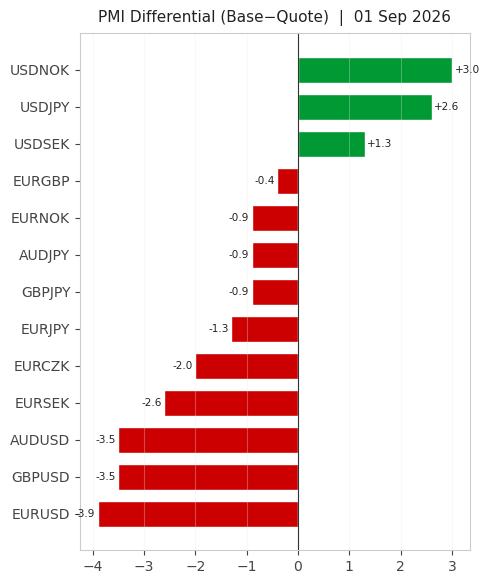

In [13]:
# ── PMI Diff chart ────────────────────────────────────────────────────────────
pmi_d = macro['PMI Diff'].dropna().sort_values(ascending=True)
colors = [BULL if v > 0 else BEAR for v in pmi_d.values]

fig, ax = plt.subplots(figsize=(5, len(pmi_d)*0.38 + 1))
ax.barh(pmi_d.index, pmi_d.values, color=colors, edgecolor='white', height=0.7)
ax.axvline(0, color='#333333', lw=0.8)
for i, (idx, val) in enumerate(pmi_d.items()):
    ax.text(val + (0.05 if val >= 0 else -0.05), i, f'{val:+.1f}',
            va='center', ha='left' if val >= 0 else 'right', fontsize=7.5)
ax.set_title(f'PMI Differential (Base−Quote)  |  {TODAY.strftime("%d %b %Y")}', fontsize=11, pad=8)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('monitor_pmi.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 7. Price Charts

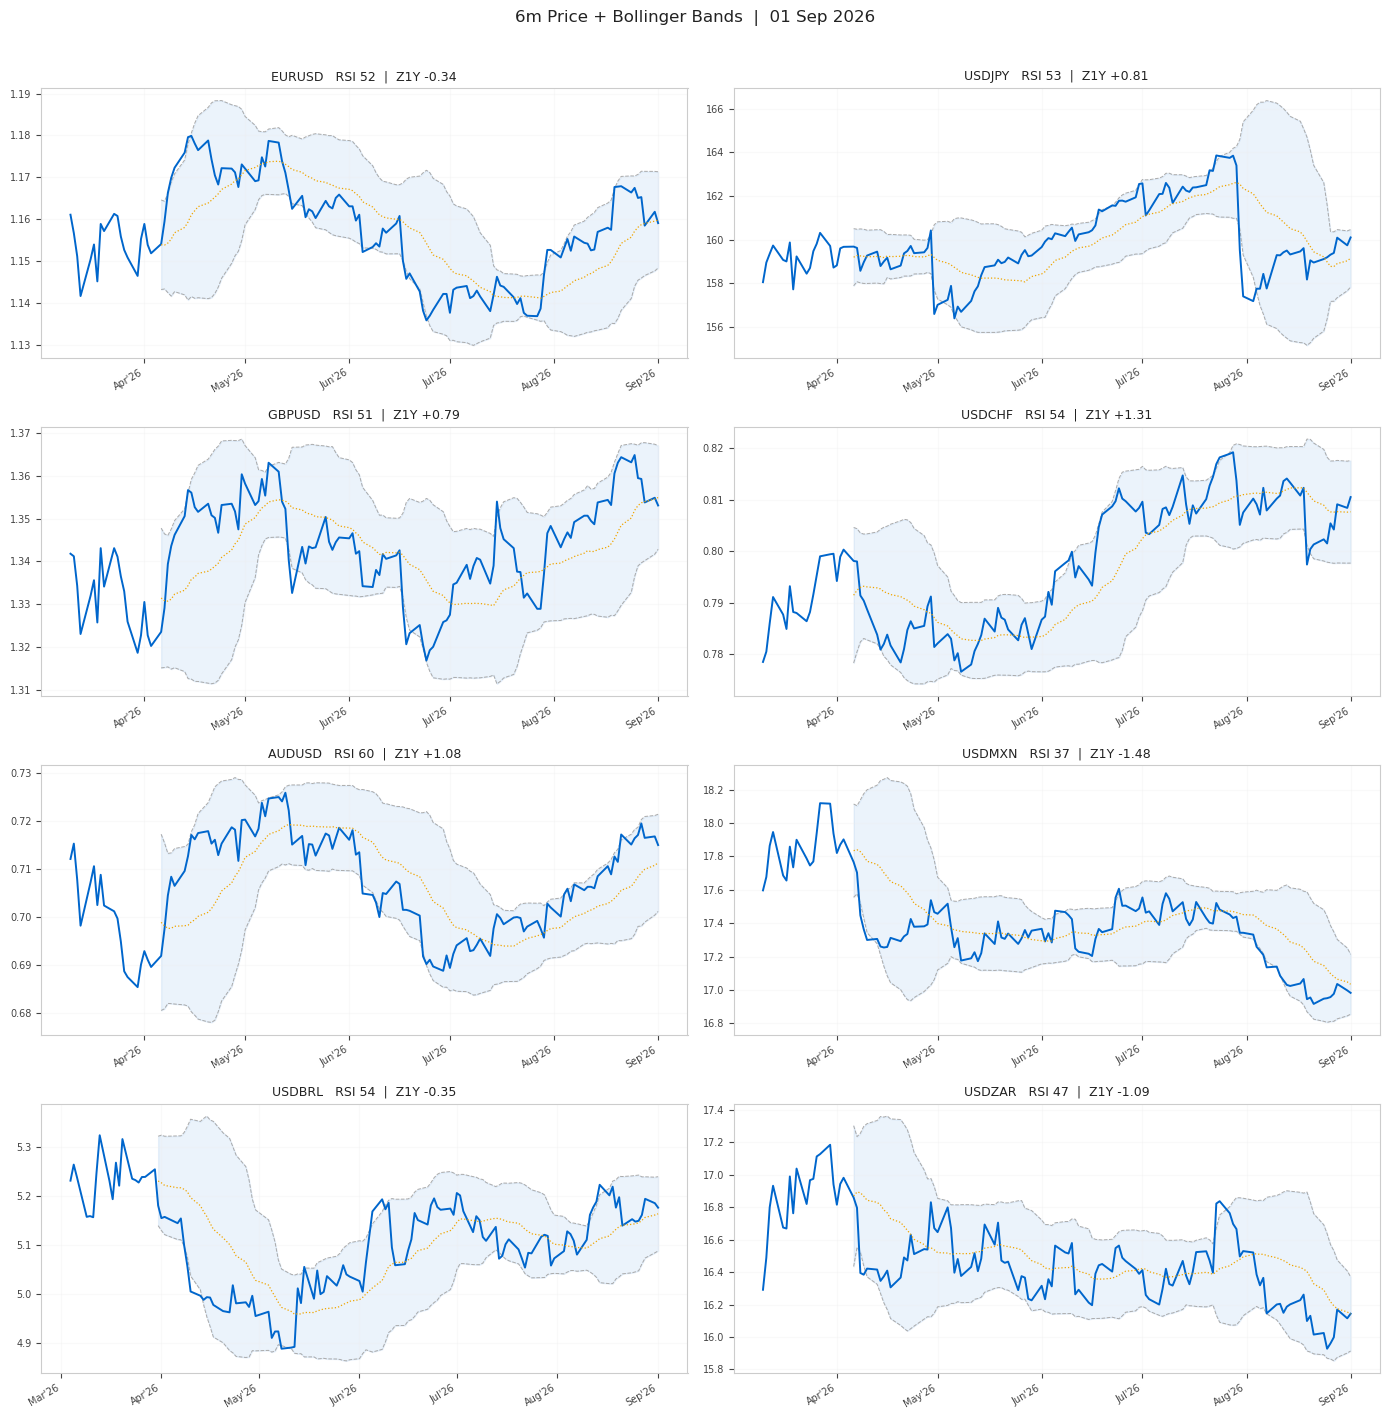

In [14]:
# ── 6-month spot charts with Bollinger Bands ──────────────────────────────────
# Edit the list below to choose which pairs to chart
CHART_PAIRS = ['EURUSD','USDJPY','GBPUSD','USDCHF','AUDUSD','USDMXN','USDBRL','USDZAR']

n = len(CHART_PAIRS)
cols = 2
rows = (n + 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(14, rows * 3.5))
axes = axes.flatten()

for i, pair in enumerate(CHART_PAIRS):
    ax = axes[i]
    if pair not in close.columns:
        ax.set_visible(False)
        continue
    px = close[pair].dropna().iloc[-126:]   # 6m
    bb = compute_bollinger(px)

    ax.fill_between(bb.index, bb['upper'], bb['lower'], alpha=0.08, color=BLUE)
    ax.plot(bb.index, bb['upper'], lw=0.7, color='#aaaaaa', ls='--')
    ax.plot(bb.index, bb['lower'], lw=0.7, color='#aaaaaa', ls='--')
    ax.plot(px.index, px.values, lw=1.4, color=BLUE, label=pair)
    ax.plot(bb.index, bb['mid'],  lw=0.9, color='#f0a500', ls=':', label='SMA20')

    rsi_v = compute_rsi(close[pair].dropna()).iloc[-1]
    z1y   = zscore(close[pair].dropna(), 252)
    ax.set_title(f'{pair}   RSI {rsi_v:.0f}  |  Z1Y {z1y:+.2f}', fontsize=9)
    ax.tick_params(labelsize=7)
    ax.grid(alpha=0.3)
    ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%b\'%y'))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right', fontsize=7)

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle(f'6m Price + Bollinger Bands  |  {TODAY.strftime("%d %b %Y")}', fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig('monitor_charts.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 8. Summary Scorecard

In [15]:
summary = pd.DataFrame(index=tech.index)
summary['Spot']           = close.iloc[-1].reindex(tech.index).round(4)
summary['ROC 1m %']       = tech['ROC 1m %']
summary['RSI(14)']        = tech['RSI(14)']
summary['Z 1Y']           = tech['Z 1Y']
summary['MACD']           = tech['MACD']
summary['Rate Diff (bps)']= carry['Rate Diff 3m (bps)']
summary['Carry/Vol']      = carry['Carry/Vol 1m']
summary['PMI Signal']     = macro['PMI Signal']
summary['CB Base']        = macro['CB Base']
summary['CB Quote']       = macro['CB Quote']

print(f'=== SUMMARY SCORECARD  |  {TODAY.strftime("%d %b %Y")} ===')
show(style_df(summary), **ITABLE_OPTS)

=== SUMMARY SCORECARD  |  01 Sep 2026 ===
